In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.cluster import DBSCAN

In [108]:
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def analyze_endpoints_file(csv_path, eps=1, min_samples=1):
    df = pd.read_csv(csv_path)

    df = df[df["d_final"] <= 19].copy()

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    X = np.column_stack([
        df["d_final"].values,
        np.cos(df["theta1_final"].values),
        np.sin(df["theta1_final"].values),
        np.cos(df["theta2_final"].values),
        np.sin(df["theta2_final"].values),
    ])

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    df["cluster"] = labels

    return df

def classify_fixed_and_loops(df, eps_loop=1.0, min_samples_loop=1, force_tol=1e-3):
    df = df.copy()

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    fixed = df[df["force_norm"] < force_tol].copy()
    fixed["attractor_type"] = "fixed"
    moving = df[df["force_norm"] >= force_tol].copy()
    moving["attractor_type"] = "loop_or_moving"

    X_fixed = np.column_stack([
        fixed["d_final"].values,
        np.cos(fixed["theta1_final"].values),
        np.sin(fixed["theta1_final"].values),
        np.cos(fixed["theta2_final"].values),
        np.sin(fixed["theta2_final"].values),
    ])
    
    if len(fixed) > 0:
        fixed_labels = DBSCAN(eps=0.12, min_samples=1).fit_predict(X_fixed)
        fixed["attractor_id"] = ["Fixed_" + str(i) for i in fixed_labels]

    X_loop = np.column_stack([
        moving["d_final"].values,
        np.cos(moving["theta1_final"].values),
        np.sin(moving["theta1_final"].values),
        np.cos(moving["theta2_final"].values),
        np.sin(moving["theta2_final"].values),
    ])

    if len(moving) > 0:
        loop_labels = DBSCAN(eps=eps_loop, min_samples=min_samples_loop).fit_predict(X_loop)
        moving["attractor_id"] = ["Moving_" + str(i) for i in loop_labels]

    return pd.concat([fixed, moving], ignore_index=True)

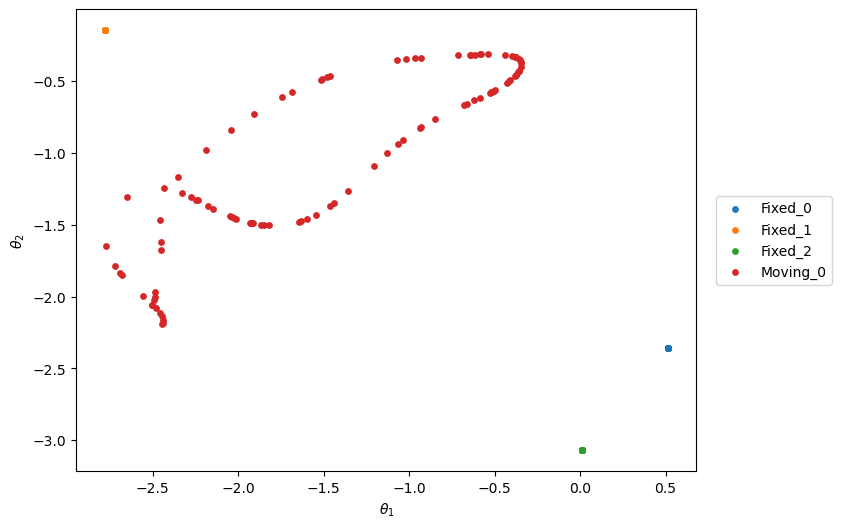

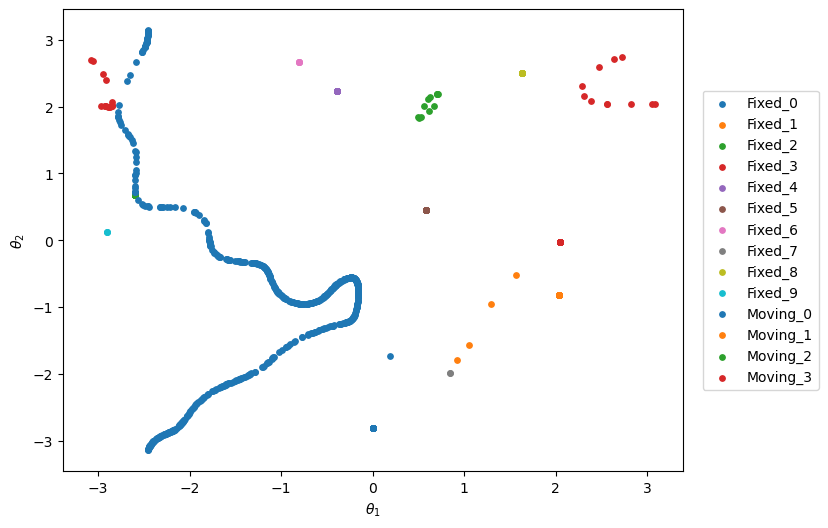

In [138]:

#result_first = analyze_endpoints_file(f"../Results/Exp_{exp_id}_fight1/Endpoints_exp{exp_id}_fight1_first_half.csv")
#result_last = analyze_endpoints_file(f"../Results/Exp_{exp_id}_fight1/Endpoints_exp{exp_id}_fight1_last_half.csv")

## exp 2
exp_id =20
result_first = analyze_endpoints_file(f"../Results_new/Exp_{exp_id}_fight2/Endpoints_exp{exp_id}_fight1_first_half.csv")
result_last = analyze_endpoints_file(f"../Results_new/Exp_{exp_id}_fight2/Endpoints_exp{exp_id}_fight1_last_half.csv")

classified_first = classify_fixed_and_loops(result_first,eps_loop=1.0,min_samples_loop=1,force_tol=1e-3)
classified_last = classify_fixed_and_loops(result_last,eps_loop=1.0,min_samples_loop=1,force_tol=1e-3)
classified_first.to_csv(f'../Results_new/Exp_{exp_id}_fight2/Classified_first.csv')
classified_last.to_csv(f'../Results_new/Exp_{exp_id}_fight2/Classified_last.csv')

plt.figure(figsize=(8,6))

for name, g in classified_first.groupby("attractor_id"):
    plt.scatter(g["theta1_final"], g["theta2_final"], s=15, label=name)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig(f'../Results_new/Exp_{exp_id}_fight2/Clustered_endpoints_first.png',bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,6))

for name, g in classified_last.groupby("attractor_id"):
    plt.scatter(g["theta1_final"], g["theta2_final"], s=15, label=name)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig(f'../Results_new/Exp_{exp_id}_fight2/Clustered_endpoints_last.png',bbox_inches="tight")
plt.show()

In [193]:
def summarize_function(df,exp_id,half):
    summary = (df.groupby(["attractor_type", "attractor_id"]).agg(
            n_points=("attractor_id", "size"),
            d_mean=("d_final", "mean"),
            theta1_mean=("theta1_final", "mean"),
            theta2_mean=("theta2_final", "mean"),
            mean_force=("force_norm", "mean"),
            mean_steps=("step_used", "mean"),

            d_std=("d_final", "std"),
            theta1_std=("theta1_final", "std"),
            theta2_std=("theta2_final", "std"),).reset_index())

    summary["attractor_fraction"] = (summary["n_points"] / len(df))
    summary["exp_id"] = exp_id
    summary["half"] = half

    return summary


all_sumaries = []
exp_runagain = [7,8,13]
exp_ids = [2,3,5,10,12,15,18,19,20]


for exp_id in exp_ids:
    first_path = f"../Results_new/Exp_{exp_id}_fight2/Classified_first.csv"
    last_path  = f"../Results_new/Exp_{exp_id}_fight2/Classified_last.csv"
    df_first = pd.read_csv(first_path)
    df_last = pd.read_csv(last_path)

    summary_first = summarize_function(df_first,exp_id,"first")
    summary_last = summarize_function(df_last,exp_id,"last")
    all_sumaries.append(summary_first)
    all_sumaries.append(summary_last)

for exp_id1 in exp_runagain:
    first_path = f"../Results/Exp_{exp_id1}_fight1/Classified_first.csv"
    last_path  = f"../Results/Exp_{exp_id1}_fight1/Classified_last.csv"
    df_first = pd.read_csv(first_path)
    df_last = pd.read_csv(last_path)

    summary_first = summarize_function(df_first,exp_id1,"first")
    summary_last = summarize_function(df_last,exp_id1,"last")
    all_sumaries.append(summary_first)
    all_sumaries.append(summary_last)

complete_summary = pd.concat(all_sumaries, ignore_index=True)
complete_summary.to_csv("../Results_new/complete_attractor_summary.csv",index = False)

In [194]:
summary_df = pd.read_csv("../Results_new/complete_attractor_summary.csv")
print(summary_df.head(10))


   attractor_type attractor_id  n_points    d_mean  theta1_mean  theta2_mean  \
0           fixed      Fixed_0      1408  2.509541     2.770609     0.089730   
1           fixed      Fixed_1         8  7.673016    -2.809160     0.139837   
2           fixed      Fixed_2        35  4.708411    -2.728564     0.058398   
3  loop_or_moving     Moving_0        19  2.509264     2.780457     0.086963   
4  loop_or_moving     Moving_1         2  1.073055    -1.322300     0.368348   
5  loop_or_moving    Moving_10         2  2.435585    -2.001488     0.297009   
6  loop_or_moving    Moving_11         2  0.977910     2.058495     0.533868   
7  loop_or_moving    Moving_12         1  4.175876     1.820817    -1.252872   
8  loop_or_moving    Moving_13         1  1.945296     1.531237    -2.488295   
9  loop_or_moving    Moving_14         1  4.568107    -0.156653     1.948389   

   mean_force   mean_steps     d_std  theta1_std  theta2_std  \
0    0.000648  1772.529830  0.000102    0.000041    0.0

In [160]:
dominant_first = summary_df[(summary_df["basin_fraction"]>0.) &(complete_summary["attractor_type"] == "loop_or_moving")& (summary_df["half"]=="first")]
dominant_last = summary_df[(summary_df["basin_fraction"]>0.) & (complete_summary["attractor_type"] == "loop_or_moving")&(summary_df["half"]=="last")]
print(dominant_first.shape,dominant_last.shape)

(42, 15) (31, 15)


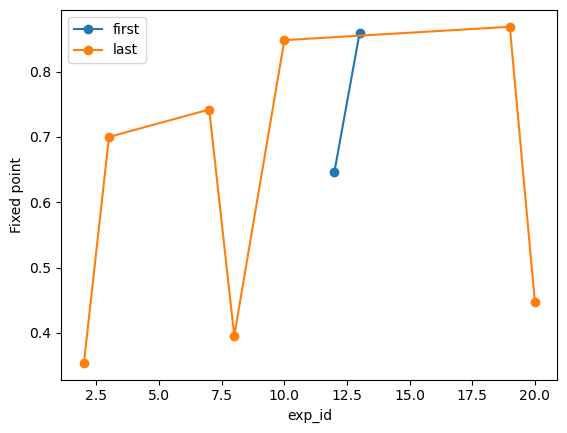

In [185]:
df = summary_df[(summary_df["basin_fraction"] > 0.3) &(summary_df["attractor_type"] == "loop_or_moving")]
first = (df[df["half"] == "first"].groupby("exp_id")["basin_fraction"].sum().sort_index())
last = (df[df["half"] == "last"].groupby("exp_id")["basin_fraction"].sum().sort_index())
plt.plot(first.index, first.values, label="first",marker = "o")
plt.plot(last.index, last.values, label="last",marker = "o")
plt.xlabel("exp_id")
plt.ylabel("Fixed point")
plt.legend()
plt.show()

In [187]:
avg_basin = (
    summary_df
    .groupby("half")["basin_fraction"]
    .mean()
)

n_attr = (
    summary_df
    .groupby(["exp_id", "half"])
    .size()
    .reset_index(name="n_attractors")
)

print(n_attr)

    exp_id   half  n_attractors
0        2  first            19
1        2   last             6
2        3  first             8
3        3   last             4
4        5  first             9
5        5   last            13
6        7  first             6
7        7   last             5
8        8  first            11
9        8   last            10
10      10  first            11
11      10   last            10
12      12  first             8
13      12   last             7
14      13  first             5
15      13   last             5
16      15  first            10
17      15   last            19
18      18  first             9
19      18   last             7
20      19  first            10
21      19   last             2
22      20  first             4
23      20   last            14


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_77286/236288166.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([first,last], labels=["first","last"])


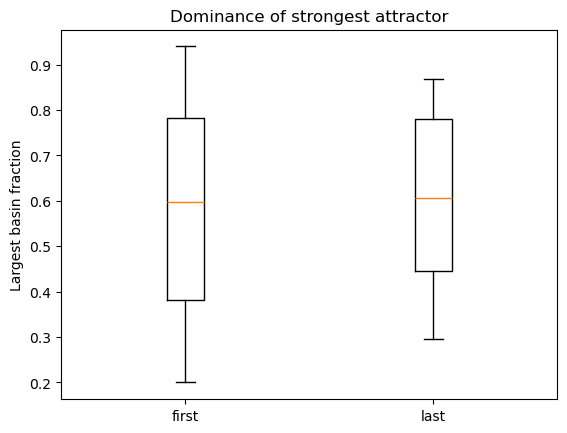

In [177]:
largest = (
    summary_df
    .groupby(["exp_id","half"])["basin_fraction"]
    .max()
    .reset_index()
)

first = largest[largest["half"]=="first"]["basin_fraction"]
last  = largest[largest["half"]=="last"]["basin_fraction"]

plt.boxplot([first,last], labels=["first","last"])
plt.ylabel("Largest basin fraction")
plt.title("Dominance of strongest attractor")
plt.show()

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_77286/1587721208.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([first,last], labels=["first","last"])


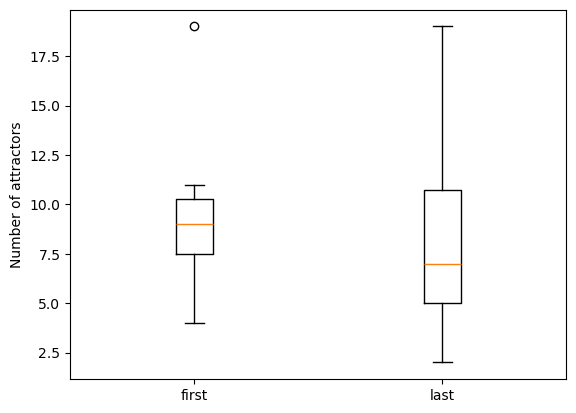

In [178]:
counts = (
    summary_df
    .groupby(["exp_id","half"])
    .size()
    .reset_index(name="n_attractors")
)

first = counts[counts["half"]=="first"]["n_attractors"]
last  = counts[counts["half"]=="last"]["n_attractors"]

plt.boxplot([first,last], labels=["first","last"])
plt.ylabel("Number of attractors")
plt.show()

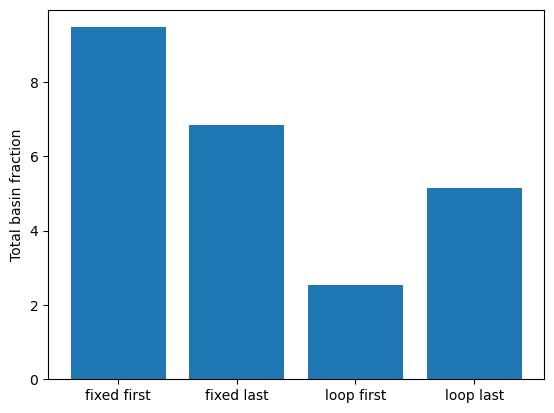

In [180]:
fixed = summary_df[summary_df["attractor_type"]=="fixed"]
loops = summary_df[summary_df["attractor_type"]=="loop_or_moving"]

fixed_first = fixed[fixed["half"]=="first"]["basin_fraction"].sum()
fixed_last  = fixed[fixed["half"]=="last"]["basin_fraction"].sum()

loop_first = loops[loops["half"]=="first"]["basin_fraction"].sum()
loop_last  = loops[loops["half"]=="last"]["basin_fraction"].sum()

plt.bar(
    ["fixed first","fixed last","loop first","loop last"],
    [fixed_first,fixed_last,loop_first,loop_last]
)
plt.ylabel("Total basin fraction")
plt.show()

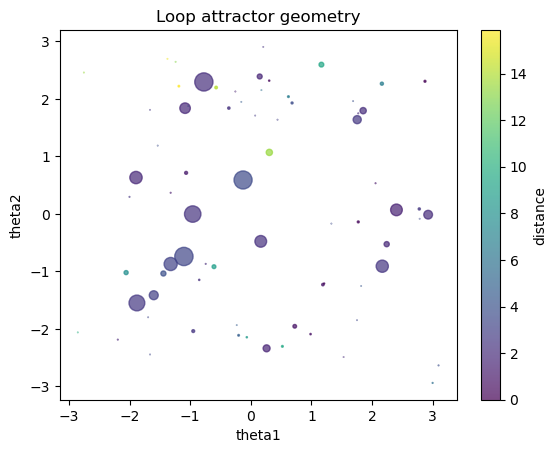

In [181]:
loops = summary_df[summary_df["attractor_type"]=="loop_or_moving"]

plt.scatter(
    loops["theta1_mean"],
    loops["theta2_mean"],
    s=200*loops["basin_fraction"],
    c=loops["d_mean"],
    alpha=0.7
)

plt.xlabel("theta1")
plt.ylabel("theta2")
plt.colorbar(label="distance")
plt.title("Loop attractor geometry")
plt.show()

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_77286/1988108570.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([first,last], labels=["first","last"])


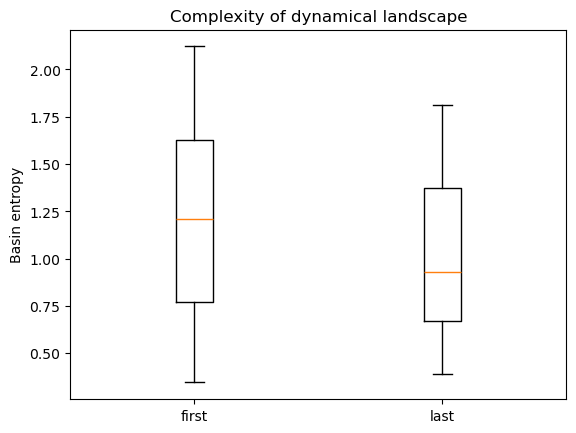

In [182]:
import numpy as np

entropy = (
    summary_df
    .groupby(["exp_id","half"])["basin_fraction"]
    .apply(lambda p: -(p*np.log(p+1e-10)).sum())
    .reset_index(name="entropy")
)

first = entropy[entropy["half"]=="first"]["entropy"]
last  = entropy[entropy["half"]=="last"]["entropy"]

plt.boxplot([first,last], labels=["first","last"])
plt.ylabel("Basin entropy")
plt.title("Complexity of dynamical landscape")
plt.show()

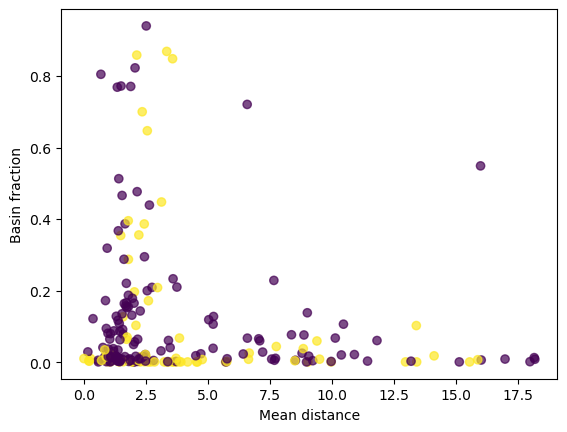

In [183]:
plt.scatter(
    summary_df["d_mean"],
    summary_df["basin_fraction"],
    c=(summary_df["attractor_type"]=="loop_or_moving"),
    alpha=0.7
)

plt.xlabel("Mean distance")
plt.ylabel("Basin fraction")
plt.show()